In [ ]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np 

**Enačbe za 3 DoF in izpisana enačba za telo 1**

$$m_1 \ddot{x}_1 
+ (c_1 + c_2) \dot{x}_1 
- c_2 \dot{x}_2 
+ (k_1 + k_2) x_1 
- k_2 x_2 
= f_1
$$


$$
\mathbf{M} =
\begin{bmatrix}
m_1 & 0   & 0   \\
0   & m_2 & 0   \\
0   & 0   & m_3
\end{bmatrix},
\quad
\mathbf{C} =
\begin{bmatrix}
c_1 + c_2 & -c_2      & 0          \\
-c_2      & c_2 + c_3 & -c_3       \\
0         & -c_3      & c_3 + c_4
\end{bmatrix},
\quad
\mathbf{K} =
\begin{bmatrix}
k_1 + k_2 & -k_2      & 0          \\
-k_2      & k_2 + k_3 & -k_3       \\
0         & -k_3      & k_3 + k_4
\end{bmatrix},

$$


$$
\mathbf{F} =
\begin{Bmatrix}
f_1 \\
f_2 \\
f_3
\end{Bmatrix},
\quad
\mathbf{x} =
\begin{Bmatrix}
x_1 \\
x_2 \\
x_3
\end{Bmatrix}
$$

$$
\mathbf{M} \ddot{\mathbf{x}} + \mathbf{C} \dot{\mathbf{x}} + \mathbf{K} \mathbf{x} = \mathbf{F}.
$$

In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np 

# Number of degrees of freedom (DOF)
n_dof = 5

# Define symbolic variables for masses, damping coefficients, and stiffness constants
masses = sp.symbols(f'm_1:{n_dof + 1}')  # m_1, m_2, ..., m_5
dampings = sp.symbols(f'c_1:{n_dof + 2}')  # c_1, c_2, ..., c_5
stiffnesses = sp.symbols(f'k_1:{n_dof + 2}')  # k_1, k_2, ..., k_5

# Mass matrix (diagonal)
M = sp.diag(*masses)

# Pretty printing with LaTeX format (useful for output)
sp.init_printing()

# Printing the symbolic matrices in the console
print("Mass Matrix (M):")
sp.pprint(M)



Mass Matrix (M):
⎡m₁  0   0   0   0 ⎤
⎢                  ⎥
⎢0   m₂  0   0   0 ⎥
⎢                  ⎥
⎢0   0   m₃  0   0 ⎥
⎢                  ⎥
⎢0   0   0   m₄  0 ⎥
⎢                  ⎥
⎣0   0   0   0   m₅⎦


In [2]:
dampings, stiffnesses

In [3]:
# Damping matrix (symbolic, symmetric tridiagonal)
C = sp.zeros(n_dof)
for i in range(n_dof):
    C[i, i] += dampings[i] + dampings[i + 1]
    if i < n_dof - 1:
        C[i, i + 1] -= dampings[i+1]  # Coupling with the previous block
        C[i + 1, i] -= dampings[i+1]  # Symmetric entry

print("\nDamping Matrix (C):")
sp.pprint(C[:4, :4])


Damping Matrix (C):
⎡c₁ + c₂    -c₂       0        0   ⎤
⎢                                  ⎥
⎢  -c₂    c₂ + c₃    -c₃       0   ⎥
⎢                                  ⎥
⎢   0       -c₃    c₃ + c₄    -c₄  ⎥
⎢                                  ⎥
⎣   0        0       -c₄    c₄ + c₅⎦


In [4]:
# Stiffness matrix (symbolic, symmetric tridiagonal)
K = sp.zeros(n_dof)
for i in range(n_dof):
    K[i, i] += stiffnesses[i] + stiffnesses[i + 1]
    if i < n_dof - 1:
        K[i, i + 1] -= stiffnesses[i+1]  # Koupling with the previous bloKk
        K[i + 1, i] -= stiffnesses[i+1]  # Symmetric entry

print("\nStiffness Matrix (K):")
sp.pprint(K[:4, :4])


Stiffness Matrix (K):
⎡k₁ + k₂    -k₂       0        0   ⎤
⎢                                  ⎥
⎢  -k₂    k₂ + k₃    -k₃       0   ⎥
⎢                                  ⎥
⎢   0       -k₃    k₃ + k₄    -k₄  ⎥
⎢                                  ⎥
⎣   0        0       -k₄    k₄ + k₅⎦


### Nedušen sistem

$$
\mathbf{M} \ddot{\mathbf{x}} + \mathbf{K} \mathbf{x} = \mathbf{0}.
$$

$$\begin{Bmatrix}
x(t)
\end{Bmatrix}
= 
\begin{Bmatrix}
\overline{X}
\end{Bmatrix} e^{i \omega t}
$$

In [5]:
# Define the actual numerical values for masses, damping coefficients, and stiffness constants
# define masses_values for n_dof, all are equal to 1
masses_values = [1.0] * n_dof  # Example: all masses = 1 kg 
masses_values[1: 3] = 2.0, 2.0
damping_values = [0.2] * (n_dof+1) # Example: all damping coefficients = 0.2 Ns/m
stiffness_values = [100.0] * (n_dof+1)  # Example: all stiffness = 100 N/m

# Substitute the numeric values into the symbolic matrices
substituted_M = M.subs({masses[i]: masses_values[i] for i in range(n_dof)})
substituted_C = C.subs({dampings[i]: damping_values[i] for i in range(n_dof+1)})
substituted_K = K.subs({stiffnesses[i]: stiffness_values[i] for i in range(n_dof+1)})

# Pretty printing with LaTeX format (useful for output)
sp.init_printing()

# Printing the substituted numeric matrices
print("Mass Matrix (M) with substituted values:")
sp.pprint(substituted_M[:5, :5])

print("\nDamping Matrix (C) with substituted values:")
sp.pprint(substituted_C[:5, :5])

print("\nStiffness Matrix (K) with substituted values:")
sp.pprint(substituted_K[:5, :5])



Mass Matrix (M) with substituted values:
⎡1.0   0    0    0    0 ⎤
⎢                       ⎥
⎢ 0   2.0   0    0    0 ⎥
⎢                       ⎥
⎢ 0    0   2.0   0    0 ⎥
⎢                       ⎥
⎢ 0    0    0   1.0   0 ⎥
⎢                       ⎥
⎣ 0    0    0    0   1.0⎦

Damping Matrix (C) with substituted values:
⎡0.4   -0.2   0     0     0  ⎤
⎢                            ⎥
⎢-0.2  0.4   -0.2   0     0  ⎥
⎢                            ⎥
⎢ 0    -0.2  0.4   -0.2   0  ⎥
⎢                            ⎥
⎢ 0     0    -0.2  0.4   -0.2⎥
⎢                            ⎥
⎣ 0     0     0    -0.2  0.4 ⎦

Stiffness Matrix (K) with substituted values:
⎡200.0   -100.0    0       0       0   ⎤
⎢                                      ⎥
⎢-100.0  200.0   -100.0    0       0   ⎥
⎢                                      ⎥
⎢  0     -100.0  200.0   -100.0    0   ⎥
⎢                                      ⎥
⎢  0       0     -100.0  200.0   -100.0⎥
⎢                                      ⎥
⎣  0       0       0     -

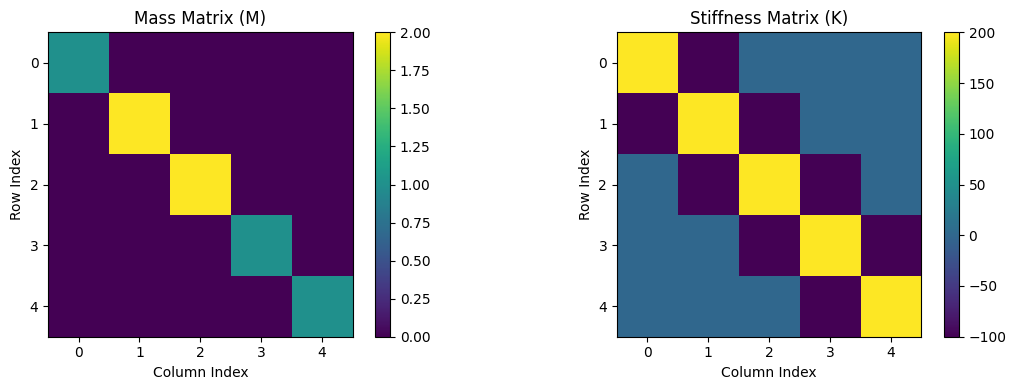

In [6]:
# Function to plot matrices as heatmaps
def plot_matrix(matrix, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(np.array(matrix).astype(np.float64), cmap="viridis", interpolation="nearest")
    plt.colorbar(label="Value")
    plt.title(title)
    plt.xlabel("Column Index")
    plt.ylabel("Row Index")
    plt.show()

# Plot the matrices side by side
def plot_matrices_side_by_side(matrices, titles):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 3 columns
    for ax, matrix, title in zip(axes, matrices, titles):
        im = ax.imshow(np.array(matrix).astype(np.float64), cmap="viridis", interpolation="nearest")
        ax.set_title(title)
        ax.set_xlabel("Column Index")
        ax.set_ylabel("Row Index")
        fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# Matrices and titles
matrices = [substituted_M, substituted_C, substituted_K]
titles = ["Mass Matrix (M)", "Damping Matrix (C)", "Stiffness Matrix (K)"]

# Matrices and titles
matrices = [substituted_M, substituted_K]
titles = ["Mass Matrix (M)", "Stiffness Matrix (K)"]

# Plot the matrices
plot_matrices_side_by_side(matrices, titles)


In [7]:
#convert substituted matrices to np.array
M = np.array(substituted_M).astype(np.float64)
C = np.array(substituted_C).astype(np.float64)
K = np.array(substituted_K).astype(np.float64)

$$
\begin{bmatrix}
A
\end{bmatrix}
= 

\begin{bmatrix}
\begin{bmatrix}
K
\end{bmatrix}
- 
\omega^2
\begin{bmatrix}
M
\end{bmatrix}
\end{bmatrix}
$$

In [8]:
A = np.linalg.inv(M)@K
A[:6, :6]

array([[ 200., -100.,    0.,    0.,    0.],
       [ -50.,  100.,  -50.,    0.,    0.],
       [   0.,  -50.,  100.,  -50.,    0.],
       [   0.,    0., -100.,  200., -100.],
       [   0.,    0.,    0., -100.,  200.]])

#### Lastne vrednosti, oblike, sortiranje

In [9]:
w, v = np.linalg.eig(A)
idx = w.argsort()[::1]
w = w[idx]
v = v[:, idx]
print("Lastne frekvence:")
for i in range(5):
    print(f"{np.sqrt(w[i]):.3f} Hz")

Lastne frekvence:
4.078 Hz
8.940 Hz
12.247 Hz
15.494 Hz
17.702 Hz


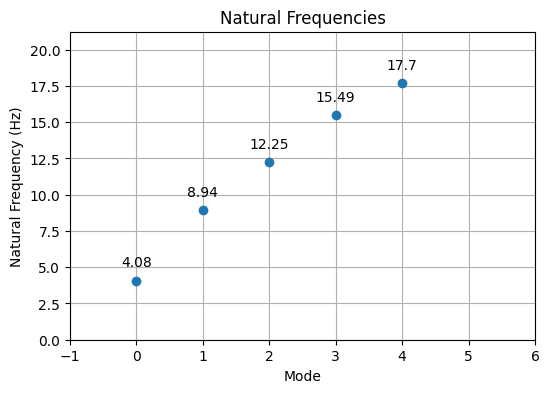

In [10]:
fig, ax = plt.subplots(figsize=(4+ n_dof*0.4, 4 ))
ax.plot(np.sqrt(w.real), 'o')
ax.set_xlabel('Mode')
ax.set_ylabel('Natural Frequency (Hz)')
ax.set_title('Natural Frequencies')
ax.set_ylim([0, 1.2*np.sqrt(max(w.real))])
ax.set_xlim([-1, n_dof+1])
for i, txt in enumerate(np.round(np.sqrt(w.real), 2)):
    ax.annotate(txt, (i, np.sqrt(w.real)[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.grid()
plt.show()

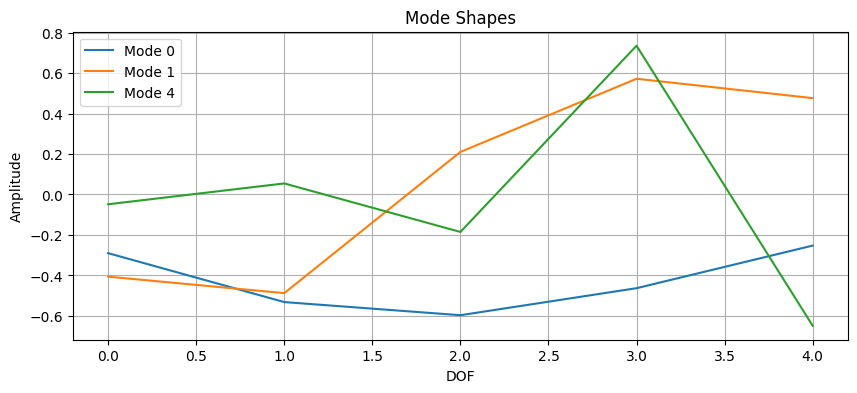

In [11]:
# plot mode shapes all in one plot only different colors. let me define which modes to show
modes = [0, 1, 4]
fig, ax = plt.subplots(figsize=(10, 4))
for i in modes:
    ax.plot(v[:, i], label=f'Mode {i}')
ax.set_xlabel('DOF')
ax.set_ylabel('Amplitude')
ax.set_title('Mode Shapes')
ax.legend()
plt.grid()
plt.show()

#### Preverjanje ortogonalnosti lastnih vektorjev

In [12]:
s = 1 #indeks 1
r = 2 #indeks 2
v[:, s].T @  M @ v[:, r]

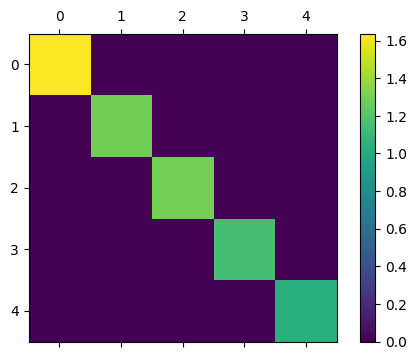

In [13]:
fig, ax = plt.subplots(figsize=(4+ n_dof*0.4, 4 ))
ax.imshow(v.T @ M @ v, cmap='viridis')
fig.colorbar(ax.matshow(v.T @ M @ v, cmap='viridis'))

#### Modal mass and stiffness

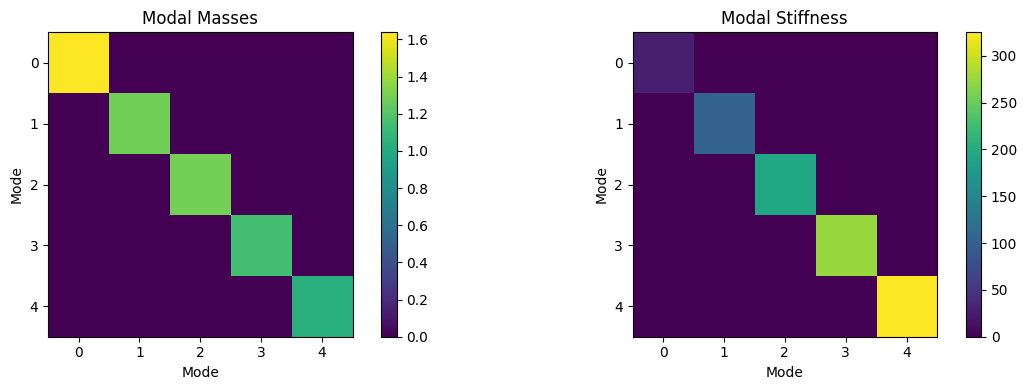

Modal Mass 0: 1.64 kg
Modal Mass 1: 1.28 kg
Modal Mass 2: 1.29 kg
Modal Mass 3: 1.15 kg
Modal Mass 4: 1.04 kg


In [14]:
#define modal stiffness and modal masses 
modal_stiffness = v.T @ K @ v
modal_masses = v.T @ M @ v
# plot modal masses and modal stiffness with imshhow
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
im1 = ax[0].imshow(modal_masses, cmap='viridis')
ax[0].set_title('Modal Masses')
ax[0].set_xlabel('Mode')
ax[0].set_ylabel('Mode')
fig.colorbar(im1, ax=ax[0], orientation='vertical')
im2 = ax[1].imshow(modal_stiffness, cmap='viridis')
ax[1].set_title('Modal Stiffness')
ax[1].set_xlabel('Mode')
ax[1].set_ylabel('Mode')
fig.colorbar(im2, ax=ax[1], orientation='vertical')
plt.tight_layout()
plt.show()


for i in range(len(modal_masses)):
    print(f'Modal Mass {i}: {modal_masses[i, i]:.2f} kg')


#### Preverjanje modalnih mas

In [15]:
A_2 = np.linalg.inv(modal_masses)@modal_stiffness
w_2, v_2 = np.linalg.eig(A_2);

idx = w_2.argsort()[::1]
w_2 = w_2[idx]
v_2 = v_2[:,idx]

print("Lastne frekvence z modalnimi masami:")
for i in range(5):
    print(f"{np.sqrt(w_2[i]):.3f} Hz")

print("-------------------------")
print("Primerjava lastnih frekvenc:")
for i in range(5):
    print(f"Mode {i}: {np.sqrt(w[i]):.3f} Hz, {np.sqrt(w_2[i]):.3f} Hz")

Lastne frekvence z modalnimi masami:
4.078 Hz
8.940 Hz
12.247 Hz
15.494 Hz
17.702 Hz
-------------------------
Primerjava lastnih frekvenc:
Mode 0: 4.078 Hz, 4.078 Hz
Mode 1: 8.940 Hz, 8.940 Hz
Mode 2: 12.247 Hz, 12.247 Hz
Mode 3: 15.494 Hz, 15.494 Hz
Mode 4: 17.702 Hz, 17.702 Hz


$$
\lambda_r = \frac{k_r}{m_r}
$$

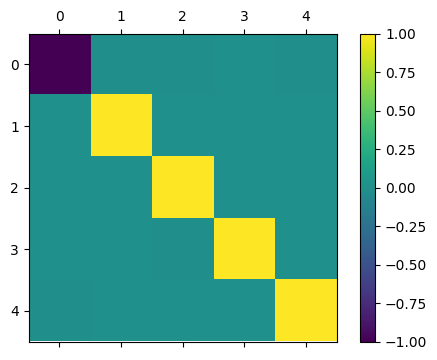

In [16]:
#imshow v2
fig, ax = plt.subplots(figsize=(4+ n_dof*0.4, 4 ))
ax.imshow(v_2, cmap='viridis')
fig.colorbar(ax.matshow(v_2, cmap='viridis'))

In [17]:
modal_masses

array([[ 1.63804928e+00,  1.32159159e-15,  6.15457688e-16,
        -4.29659335e-16,  3.99352195e-16],
       [ 1.32159159e-15,  1.28169327e+00, -7.17526897e-18,
        -4.49578321e-16,  2.49077726e-17],
       [ 6.15457688e-16, -7.17526897e-18,  1.29411765e+00,
         5.67495946e-16, -4.17348014e-16],
       [-4.29659335e-16, -4.49578321e-16,  5.67495946e-16,
         1.14618263e+00, -1.03447619e-15],
       [ 3.99352195e-16,  2.49077726e-17, -4.17348014e-16,
        -1.03447619e-15,  1.03722465e+00]])

Modal Masses:
Mode 0: 1.64 kg
Mode 1: 1.28 kg
Mode 2: 1.29 kg
Mode 3: 1.15 kg
Mode 4: 1.04 kg


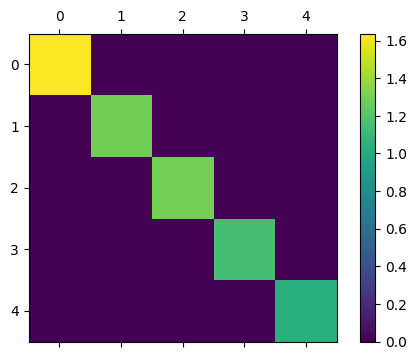

In [18]:
#imshow modalmasses
fig, ax = plt.subplots(figsize=(4+ n_dof*0.4, 4 ))
ax.imshow(modal_masses, cmap='viridis')
fig.colorbar(ax.matshow(modal_masses, cmap='viridis'))

print("Modal Masses:")
for i in range(5):
    print(f"Mode {i}: {modal_masses[i, i]:.2f} kg")

Modal stiffneses:
Mode 0: 27.24 kg
Mode 1: 102.45 kg
Mode 2: 194.12 kg
Mode 3: 275.15 kg
Mode 4: 325.04 kg


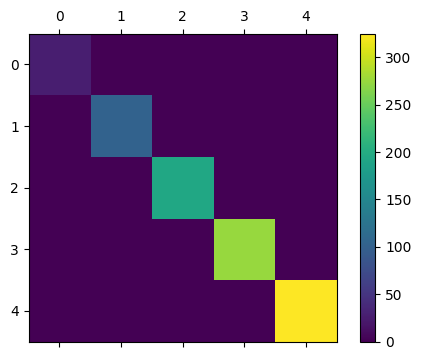

In [19]:
#imshow modalmasses
fig, ax = plt.subplots(figsize=(4+ n_dof*0.4, 4 ))
ax.imshow(modal_stiffness, cmap='viridis')
fig.colorbar(ax.matshow(modal_stiffness, cmap='viridis'))

print("Modal stiffneses:")
for i in range(5):
    print(f"Mode {i}: {modal_stiffness[i, i]:.2f} kg")

In [20]:
for i in range(n_dof):
    print(f"Mode {i}: {modal_masses[i, i]:.2f} kg")
    print(f"Mode {i}: {modal_stiffness[i, i]:.2f} kg")

Mode 0: 1.64 kg
Mode 0: 27.24 kg
Mode 1: 1.28 kg
Mode 1: 102.45 kg
Mode 2: 1.29 kg
Mode 2: 194.12 kg
Mode 3: 1.15 kg
Mode 3: 275.15 kg
Mode 4: 1.04 kg
Mode 4: 325.04 kg


In [22]:
A_2 = np.linalg.inv(modal_masses)@modal_stiffness
w2_2, v_2 = np.linalg.eig(A_2);

print("Lastne frekvence z modalnimi masami:")
for i in range(5):
    print(f"{np.sqrt(w2_2[i]):.3f} Hz")

print("-------------------------")
print("Primerjava lastnih frekvenc:")
for i in range(5):
    print(f"Mode {i}: {np.sqrt(w2[i]):.3f} Hz, {np.sqrt(w_2[i]):.3f} Hz")

Lastne frekvence z modalnimi masami:
4.078 Hz
17.702 Hz
8.940 Hz
12.247 Hz
15.494 Hz
-------------------------
Primerjava lastnih frekvenc:


NameError: name 'w2' is not defined

In [ ]:
modal_stiffness_2 = v_2.T @ K @ v_2
modal_masses_2 = v_2.T @ M @ v_2

D = np.zeros((n_dof, n_dof))
for i in range(n_dof):
    D[i, i] = 1/np.sqrt(modal_masses_2[i, i])
    
Phi = v_2.copy()
for i in range(n_dof):
    Phi[i,i] =  Phi[i,i]*D[i,i]


In [ ]:
M[0,0], np.sqrt(modal_masses_2[0,0])

1.0
1.0
2.0
2.0
1.0


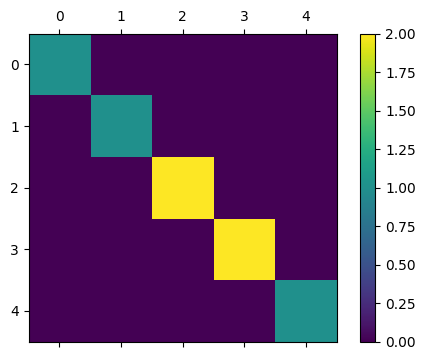

In [ ]:
graf = Phi.T @ M @ Phi
#imshow graf
fig, ax = plt.subplots(figsize=(4+ n_dof*0.4, 4 ))
ax.imshow(graf, cmap='viridis')
fig.colorbar(ax.matshow(graf, cmap='viridis'))
for i in range(n_dof):
    print(graf[i,i])